Test files at: test_data/redaction_examples

1. GE Revolution CT
    * Redaction Zone: [20, 70, 20, 500]
2. Siemens Somatom Force
    * Redaction Zone: [450, 500, 400, 512]
3. Philips Brilliance 64
    * Redaction Zone: [10, 60, 200, 512]

In [ ]:
%pip install --force-reinstall "git+https://github.com/kvnlng/Isocenter.git"

In [ ]:
%pip install pydicom matplotlib

In [27]:
import pydicom
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [28]:
filename = "scripts/test_data/redaction_examples/Subject_PID-44865/Study_2026-09-10_Study_96125/Series_1_CT_Series_125.1/1.2.840.999.96125.1.1.dcm"

ds = pydicom.dcmread(filename)

print(f"Patient's Name...: {ds.PatientName}")
print(f"Modality.........: {ds.Modality}")
print(f"Image size.......: {ds.Rows} x {ds.Columns}")

# Manufacturer
print(f"Make:  {ds.Manufacturer}")
# Model Name
print(f"Model: {ds.ManufacturerModelName}")
# Serial Number
print(f"Serial: {ds.DeviceSerialNumber}")

Patient's Name...: Pittman^Robert
Modality.........: CT
Image size.......: 512 x 512
Make:  Philips
Model: Brilliance 64
Serial: SN-9268


(5, 512, 512)


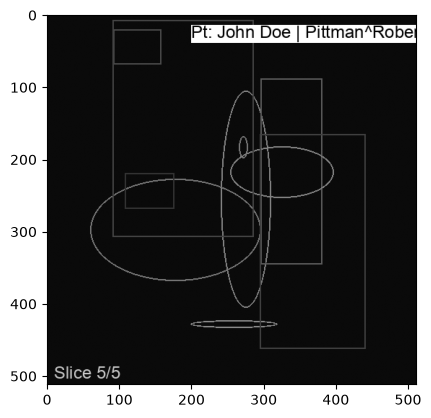

In [29]:
# Display the first frame
print(ds.pixel_array.shape)
plt.imshow(ds.pixel_array[4], cmap=cm.gray)

In [30]:
from isocenter import Session
session = Session("redaction.db")

Loading session from redaction.db...
Loaded session from redaction.db


In [31]:
session.ingest("scripts/test_data")
session.save()

Ingesting from 'scripts/test_data'...
Ingestion complete. Saved session state.
Summary:
  - 6 Patients
  - 6 Studies
  - 6 Series
  - 6 Instances


In [32]:
# Print a summary of the cohort and equipment
session.examine()


Inventory Summary:
 Patients:  6
 Studies:   6
 Series:    6
 Instances: 6

Equipment Inventory:
 - GE - Revolution CT (Count: 2)
 - Philips - Brilliance 64 (Count: 2)
 - Siemens - Somatom Force (Count: 2)


In [33]:
# Create a default configuration file
session.create_config("redaction-config.yaml")

Scaffolded Unified Config to redaction-config.yaml


In [34]:
# Load the configuration (rules, tags, jitter)
session.load_config("redaction-config.yaml")

Loading configuration from redaction-config.yaml...
Configuration Loaded:
 - 6 Machine Redaction Rules
 - 620 PHI Tags
 - Date Jitter: -365 to -1 days
 - Remove Private Tags: True
Tip: Run .audit() to check PHI, or .redact() to apply redaction.


In [35]:
from pprint import pprint
config = session.configuration

pprint(config.rules)

[{'model_name': 'Revolution CT',
  'redaction_zones': [{'note': 'RowStart, RowEnd, ColStart, ColEnd',
                       'roi': [50, 100, 50, 200]}],
  'serial_number': 'SN-6624'},
 {'model_name': 'Revolution CT',
  'redaction_zones': [{'note': 'RowStart, RowEnd, ColStart, ColEnd',
                       'roi': [50, 100, 50, 200]}],
  'serial_number': 'SN-6949'},
 {'manufacturer': 'Philips',
  'model_name': 'Brilliance 64',
  'redaction_zones': [],
  'serial_number': 'SN-9268'},
 {'manufacturer': 'Philips',
  'model_name': 'Brilliance 64',
  'redaction_zones': [],
  'serial_number': 'SN-9812'},
 {'manufacturer': 'Siemens',
  'model_name': 'Somatom Force',
  'redaction_zones': [],
  'serial_number': 'SN-1283'},
 {'manufacturer': 'Siemens',
  'model_name': 'Somatom Force',
  'redaction_zones': [],
  'serial_number': 'SN-9556'}]


In [36]:
config.update_rule(serial_number="SN-9268", updates={"redaction_zones": [[10, 60, 200, 512]]})

In [37]:
pprint(config.rules)

[{'model_name': 'Revolution CT',
  'redaction_zones': [{'note': 'RowStart, RowEnd, ColStart, ColEnd',
                       'roi': [50, 100, 50, 200]}],
  'serial_number': 'SN-6624'},
 {'model_name': 'Revolution CT',
  'redaction_zones': [{'note': 'RowStart, RowEnd, ColStart, ColEnd',
                       'roi': [50, 100, 50, 200]}],
  'serial_number': 'SN-6949'},
 {'manufacturer': 'Philips',
  'model_name': 'Brilliance 64',
  'redaction_zones': [[10, 60, 200, 512]],
  'serial_number': 'SN-9268'},
 {'manufacturer': 'Philips',
  'model_name': 'Brilliance 64',
  'redaction_zones': [],
  'serial_number': 'SN-9812'},
 {'manufacturer': 'Siemens',
  'model_name': 'Somatom Force',
  'redaction_zones': [],
  'serial_number': 'SN-1283'},
 {'manufacturer': 'Siemens',
  'model_name': 'Somatom Force',
  'redaction_zones': [],
  'serial_number': 'SN-9556'}]


In [45]:
session.redact()

Queued 3 redaction tasks across 6 rules.
Executing using 7 workers (processes)...


Redacting Pixels: 100%|██████████| 3/3 [00:07<00:00,  2.60s/it]

Redaction complete: 0 of 3 images updated. Remember to call .save() to persist.


0

In [ ]:
session.export("redacted_dicoms")

In [47]:
redacted_filename = "/Volumes/Archive/gitclones/Isocenter/redacted_dicoms/Subject_PID-44865/Study_2026-09-10_Study_96125/Series_1_CT_Series_125.1/1.2.826.0.1.3680043.8.498.56561814858858813641973060480484866428.dcm"

redacted_ds = pydicom.dcmread(redacted_filename)

print(f"Patient's Name...: {redacted_ds.PatientName}")
print(f"Modality.........: {redacted_ds.Modality}")
print(f"Image size.......: {redacted_ds.Rows} x {redacted_ds.Columns}")

# Manufacturer (e.g., "GE Medical Systems", "SIEMENS")
print(f"Make:  {redacted_ds.Manufacturer}")
# Model Name (e.g., "Revolution CT", "Somatom Force")
print(f"Model: {redacted_ds.ManufacturerModelName}")
# Serial Number
print(f"Serial: {redacted_ds.DeviceSerialNumber}")

Patient's Name...: Pittman^Robert
Modality.........: CT
Image size.......: 512 x 512
Make:  Philips
Model: Brilliance 64
Serial: SN-9268


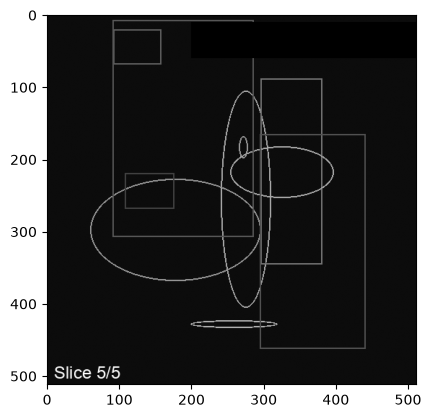

In [48]:
# Display the first frame
plt.imshow(redacted_ds.pixel_array[4], cmap=cm.gray)